In [1]:
import pandas as pd
import numpy as np
import functions as func
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

In [2]:
# #bootstrap_data_1 = [item[0] + [item[1]] for item in bootstrap_data]
#
# filename = 'data/bootstrap_data.txt'
# write_bootstrap_data_to_file(bootstrap_data_1, filename)

In [3]:
# read the bootstraps (no warner)
bt_results = np.array(func.read_bootstrap_from_file('data/bootstrap_16curves_nowerner.txt'))
full_opt_results = np.array(func.read_bootstrap_from_file('data/fullopt_data_16curves_nowerner.txt'))
print(len(bt_results), len(full_opt_results))

200 40


In [4]:
# select the best fit of all data
full_opt_idx = np.argmin(full_opt_results[:, 12])
full_opt_best = full_opt_results[full_opt_idx]
# select best bootstraps
quant = 0.1
bt_results_best = bt_results[np.where(bt_results[:, 12] <= np.quantile(bt_results[:, 12], q=quant))]

In [5]:
radar_only = np.array([1.4059, 1.1679, 0.8237, 0.9904, 0.8414, 0.5534, 5.5687, -1.2323, 6.0478, 0.2092, 1773.1715])
lc_only = np.array([1.3956, 1.1789, 0.5033, 1.073, 0.8474, 0.4968, 0.0606, -1.349, 3.4877, 0.2091, 1853.3159])
full_opt = np.array([1.3836, 0.8378, 0.8242, 1.0788, 1.0721, 0.3953, 1.9539, -1.7481, 2.2184, 0.2091, 2278.9199])

In [6]:
densities = np.array([func.estimate_density(*res[:6].T, res[9]) for res in bt_results_best]) / 1000
densities_full = np.array([func.estimate_density(*res[:6].T, res[9]) for res in full_opt_results]) / 1000
# create bins
all_dens = np.concatenate([densities, densities_full])
counts, bins = np.histogram(all_dens, bins=15)

4.81, -0.29, +0.70


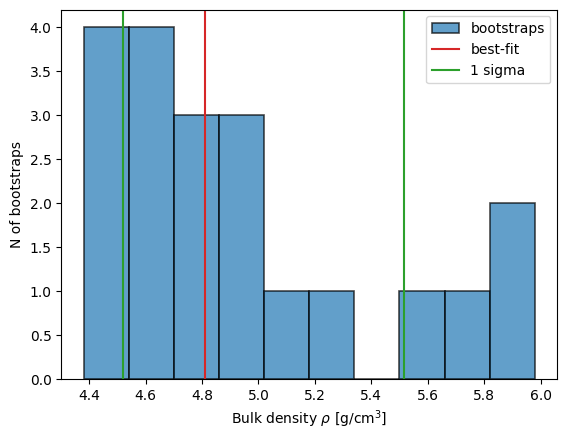

In [7]:
best_dens = func.estimate_density(*full_opt_best[:6].T, rot_per=full_opt_best[9]) / 1000
#mcmc_dens = func.estimate_density(*best_params[:6].T, rot_per=best_params[9])
plt.hist(densities, bins=10, edgecolor='black', linewidth=1.2, density=False, alpha=0.7, label='bootstraps')
#plt.hist(densities_full, bins=bins, edgecolor='black', linewidth=1.2, density=False, alpha=0.7, label='full data')
plt.axvline(best_dens, color='tab:red', label='best-fit')
#plt.axvline(mcmc_dens, color='tab:orange')
density_q17 = np.quantile(densities, 0.17)
density_q83 = np.quantile(densities, 0.83)
plt.axvline(density_q17, color='tab:green', label='1 sigma')
plt.axvline(density_q83, color='tab:green')
plt.xlabel((r"Bulk density $\rho$ [g/cm$^3$]"))
plt.ylabel('N of bootstraps')
plt.legend()
# make y axis interger values
#plt.yticks(np.arange(0, 22, 2))
#plt.savefig('article_images/bulk_density.pdf', bbox_inches='tight', format='pdf')
print(f"{best_dens:.2f}, {-(best_dens - density_q17):.2f}, +{(density_q83 - best_dens):.2f}")

In [8]:
results = np.array(bt_results_best)[:, :]
deviation = np.round(np.mean([(full_opt_best / 2 - results[i] / 2) ** 2 for i in range(1, len(results))], axis=0) ** 0.5, 4)[:12]
dev_lambda = np.round(np.mean(func.angle_diff(full_opt_best[6] - results[:, 6]))  ** 0.5, 4)
deviation[:6] *= 450 / 1000
deviation[6:9] *= np.degrees(1)
deviation[9] *= 24

In [9]:
pd.DataFrame(deviation, index=['a1', 'b1', 'c1', 'a2', 'b2', 'c2', 'lon', 'lat', 'init_phase', 'rot_period', 'radar_saturation', 'pow_coeff']).T.round(5)

,a1,b1,c1,a2,b2,c2,lon,lat,init_phase,rot_period,radar_saturation,pow_coeff
0,0.02466,0.0283,0.03681,0.0401,0.06358,0.01562,82.65489,6.27389,91.47844,0.0,165.9511,0.0656


In [10]:
# estimate mass from the parameters of the asteroid
density = 4.57 * 1000 # kg/m^3
a1s, b1s, c1s, a2s, b2s, c2s = bt_results_best[:, :6].T * 450
masses = 4/3 * np.pi * densities * (a1s * b1s * c1s + a2s * b2s * c2s) * 1000
mass_naive = 4/3 * np.pi * density * (a1s * b1s * c1s + a2s * b2s * c2s)

mass_q17: 1.56e+12, mass_q83: 2.61e+12
2.59e+12, -1.03e+12, +-2.59e+07


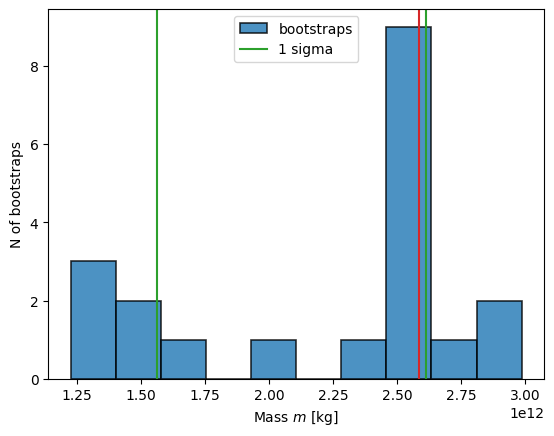

In [11]:
best_dens = func.estimate_density(*full_opt_best[:6].T, rot_per=full_opt_best[9])
a1, b1, c1, a2, b2, c2 = full_opt_best[:6].T * 450
best_mass = 4/3 * np.pi * best_dens * (a1 * b1 * c1 + a2 * b2 * c2)
plt.hist(masses, bins=10, edgecolor='black', linewidth=1.2, density=False, alpha=0.8, label='bootstraps')
#plt.axvline(best_dens/1000, color='tab:red', label='best-fit')
#plt.axvline(mcmc_dens, color='tab:orange')
mass_q17 = np.quantile(masses, 0.17)
mass_q83 = np.quantile(masses, 0.83)
plt.axvline(mass_q17, color='tab:green', label='1 sigma')
plt.axvline(mass_q83, color='tab:green')
plt.axvline(best_mass, color='tab:red')
plt.xlabel((r"Mass $m$ [kg]"))
plt.ylabel('N of bootstraps')
plt.legend()
# make y axis interger values
#plt.yticks(np.arange(0, 22, 2))
#plt.savefig('article_images/bulk_density.pdf', bbox_inches='tight', format='pdf')
print(f"mass_q17: {mass_q17:.2e}, mass_q83: {mass_q83:.2e}")
print(f"{best_mass:.2e}, {-(best_mass - mass_q17):.2e}, +{(best_mass - mass_q83)/ 1000:.2e}")

In [12]:
# compare krugly with krugly + warner data
bt_warner = np.array(func.read_bootstrap_from_file('data/bootstrap_warner_x3.txt'))
fullopt_warner = np.array(func.read_bootstrap_from_file('data/fullopt_data_werner_3xerrs.txt'))
# select the best fit of all data
fullopt_warner_idx = np.argmin(fullopt_warner[:, 12])

#fullopt_warner_best = fullopt_warner[fullopt_warner_idx]
idxs_best = np.argsort(fullopt_warner[:, 12])
fullopt_warner_best = fullopt_warner[idxs_best[0]]
# select best bootstraps
quant = 0.2
bt_warner_best = bt_warner[np.where(bt_warner[:, 12] <= np.quantile(bt_warner[:, 12], q=quant))]
print(len(bt_warner), len(fullopt_warner))

350 60


In [13]:
len(bt_warner_best)

70

In [14]:
densities_warner = np.array([func.estimate_density(*res[:6].T, res[9]) for res in bt_warner_best]) / 1000
densities_warner_full = np.array([func.estimate_density(*res[:6].T, res[9]) for res in fullopt_warner]) / 1000
all_dens_warner = np.concatenate([densities, densities_full])
counts, bins = np.histogram(all_dens_warner, bins=15)

5.200002385929828 4.303984771266582 5.665798798933068
5.20, -0.90, +0.47


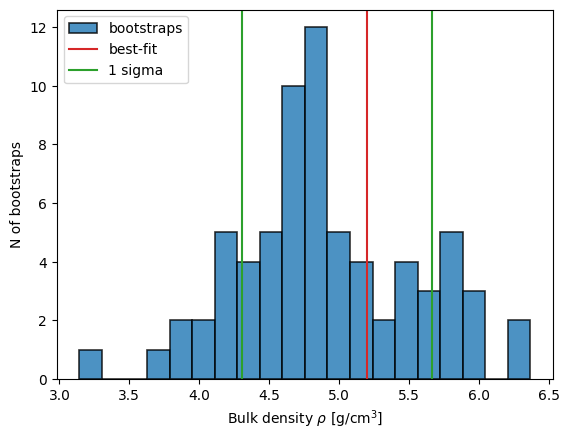

In [15]:
best_dens_warner = func.estimate_density(*fullopt_warner_best[:6].T, rot_per=fullopt_warner_best[9]) / 1000
#mcmc_dens = func.estimate_density(*best_params[:6].T, rot_per=best_params[9])
plt.hist(densities_warner, bins=20, edgecolor='black', linewidth=1.2, density=False, alpha=0.8, label='bootstraps')
#plt.hist(densities_warner_full, bins=bins, edgecolor='black', linewidth=1.2, density=False, alpha=0.8, label='full opt')
plt.axvline(best_dens_warner, color='tab:red', label='best-fit')
#plt.axvline(mcmc_dens, color='tab:orange')
density_q17_w = np.quantile(densities_warner, 0.17)
density_q83_w = np.quantile(densities_warner, 0.83)
print(best_dens_warner, density_q17_w, density_q83_w)
plt.axvline(density_q17_w, color='tab:green', label='1 sigma')
plt.axvline(density_q83_w, color='tab:green')
plt.xlabel((r"Bulk density $\rho$ [g/cm$^3$]"))
plt.ylabel('N of bootstraps')
plt.legend()
# make y axis interger values
#plt.yticks(np.arange(0, 50, 5))
#plt.savefig('article_images/bulk_density.pdf', bbox_inches='tight', format='pdf')
print(f"{best_dens_warner:.2f}, {-(best_dens_warner - density_q17_w):.2f}, +{(density_q83_w - best_dens_warner):.2f}")

5200.002385929828 320659566397.4772
mass_q17: 1.92e+11, mass_q83: 3.36e+11
3.21e+11, -1.29e+11, +1.52e+10


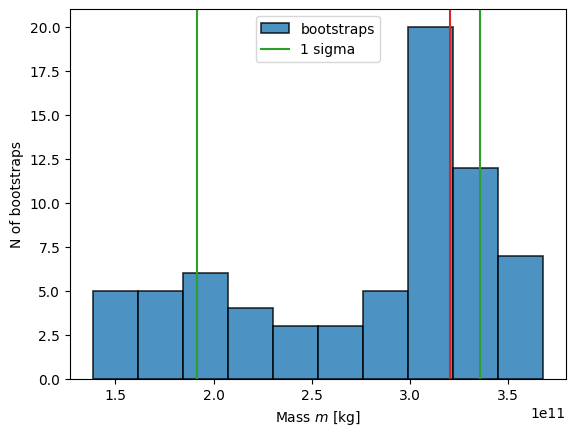

In [16]:
# estimate mass from the parameters of the asteroid
a1s, b1s, c1s, a2s, b2s, c2s = bt_warner_best[:, :6].T * 450 / 2
masses_w = 4/3 * np.pi * densities_warner * (a1s * b1s * c1s + a2s * b2s * c2s) * 1000
best_dens_w = func.estimate_density(*fullopt_warner_best[:6].T, rot_per=fullopt_warner_best[9])
a1, b1, c1, a2, b2, c2 = fullopt_warner_best[:6].T * 450 / 2
best_mass_w = 4/3 * np.pi * best_dens_w * (a1 * b1 * c1 + a2 * b2 * c2)
print(best_dens_w, best_mass_w)
#mcmc_dens = func.estimate_density(*best_params[:6].T, rot_per=best_params[9])
plt.hist(masses_w, bins=10, edgecolor='black', linewidth=1.2, density=False, alpha=0.8, label='bootstraps')
#plt.axvline(best_dens/1000, color='tab:red', label='best-fit')
#plt.axvline(mcmc_dens, color='tab:orange')
mass_q17_w = np.quantile(masses_w, 0.17)
mass_q83_w = np.quantile(masses_w, 0.83)
plt.axvline(mass_q17_w, color='tab:green', label='1 sigma')
plt.axvline(mass_q83_w, color='tab:green')
plt.axvline(best_mass_w, color='tab:red')
plt.xlabel((r"Mass $m$ [kg]"))
plt.ylabel('N of bootstraps')
plt.legend()
# make y axis interger values
#plt.yticks(np.arange(0, 22, 2))
#plt.savefig('article_images/bulk_density.pdf', bbox_inches='tight', format='pdf')
print(f"mass_q17: {mass_q17_w:.2e}, mass_q83: {mass_q83_w:.2e}")
print(f"{best_mass_w:.2e}, {-(best_mass_w - mass_q17_w):.2e}, +{(mass_q83_w - best_mass_w):.2e}")

In [17]:
def adjust_angle(params):
    # check if params is one dimensional
    if params.ndim == 1:
        long = params[6] + np.pi if params[7] < -np.pi / 2 else params[6]
        long = long - 2*np.pi if long > 2*np.pi else long
        lat = -np.pi - params[7] if params[7] < -np.pi / 2 else params[7]
        #long = params[6]
        return long, lat
    # adjust lambdas
    lambdas = params[:, 6]
    betas = params[:, 7]
    lambdas = np.where(betas < -np.pi/2, lambdas + np.pi, lambdas)
    lambdas = np.where(lambdas > 2*np.pi, lambdas - 2*np.pi, lambdas)
    # # # adjust_beta
    betas = np.where(betas < -np.pi / 2, -np.pi - betas, betas)
    #betas = np.where(betas > -1.05, -1, betas)
    return np.array([lambdas, betas]).T

In [18]:
fullopt_warner_best[6:8] = adjust_angle(fullopt_warner_best)
best_res = np.copy(fullopt_warner_best)
best_res[:6] *= 450 / 1000 / 2
best_res[6:9] *= np.degrees(1)
best_res[9] *= 24
pd.DataFrame(best_res, index=['a1', 'b1', 'c1', 'a2', 'b2', 'c2', 'lon', 'lat', 'init_phase', 'rot_period', 'radar_saturation', 'pow_coeff', 'chi2']).T.round(5)

,a1,b1,c1,a2,b2,c2,lon,lat,init_phase,rot_period,radar_saturation,pow_coeff,chi2
0,0.30505,0.18,0.16826,0.25634,0.2471,0.08656,305.36317,-80.34545,142.67222,5.0184,1994.549,2.1268,65011.70422


In [23]:
results_w = np.array(bt_warner_best)[:, :]
results_w[:, 6:8] = adjust_angle(results_w)


deviation_w = np.round(np.mean([(fullopt_warner_best / 2 - results_w[i] / 2) ** 2 for i in range(1, len(results_w))], axis=0) ** 0.5, 4)[:12]
dev_lambda_w = np.round(np.mean(func.angle_diff(fullopt_warner_best[6] - results_w[:, 6]))  ** 0.5, 4)
deviation_w[:6] *= 450 / 1000
deviation_w[6:9] *= np.degrees(1)
deviation_w[9] *= 24
pd.DataFrame(deviation_w, index=['a1', 'b1', 'c1', 'a2', 'b2', 'c2', 'lon', 'lat', 'init_phase', 'rot_period', 'radar_saturation', 'pow_coeff']).T.round(5)

,a1,b1,c1,a2,b2,c2,lon,lat,init_phase,rot_period,radar_saturation,pow_coeff
0,0.0248,0.02466,0.02934,0.03722,0.06021,0.01922,84.05291,1.50115,49.6869,0.0,145.6183,0.0425


-80.35, -3.97, +1.55


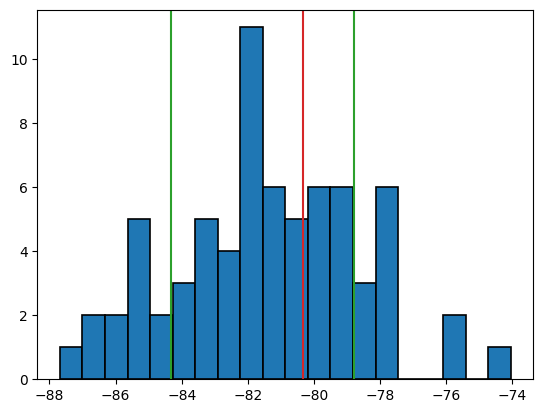

In [22]:
lats = results_w[:, 7] * np.degrees(1)
best_lat = fullopt_warner_best[7] * np.degrees(1)
plt.hist(lats, bins=20, edgecolor='black', linewidth=1.2, density=False, alpha=1.0)
q17 = np.quantile(lats, q=0.17)
q83 = np.quantile(lats, q=0.83)
plt.axvline(q17, color='tab:green', label='1 sigma')
plt.axvline(q83, color='tab:green')
plt.axvline(best_lat, color='tab:red')
print(f"{best_lat:.2f}, {-(best_lat - q17):.2f}, +{(q83 - best_lat):.2f}")

142.67, -96.58, +146.46


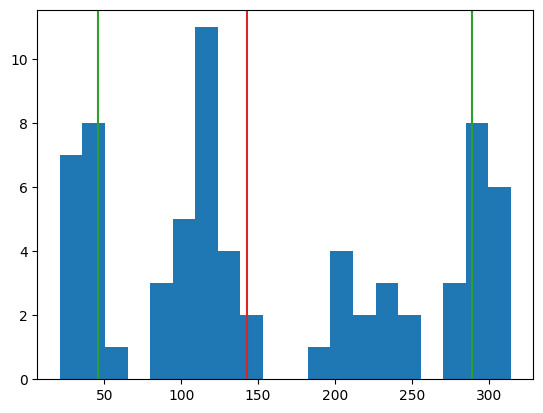

In [21]:
longs = results_w[:, 8] * np.degrees(1)
best_long= fullopt_warner_best[8] * np.degrees(1)
plt.hist(longs, bins=20)
q17 = np.quantile(longs, q=0.17)
q83 = np.quantile(longs, q=0.83)
plt.axvline(q17, color='tab:green', label='1 sigma')
plt.axvline(q83, color='tab:green')
plt.axvline(best_long, color='tab:red')
print(f"{best_long:.2f}, {-(best_long - q17):.2f}, +{(q83 - best_long):.2f}")

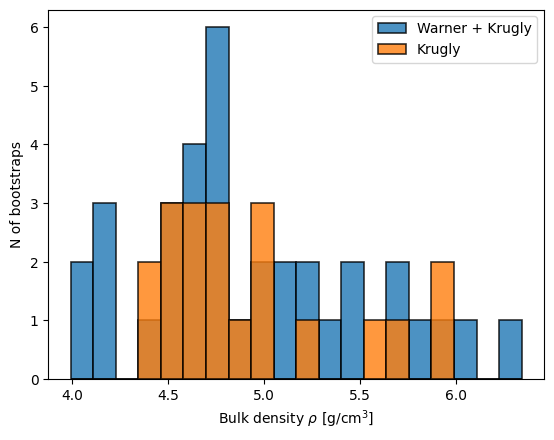

In [235]:
all_dens = np.concatenate([densities_warner, densities])
countds, bins = np.histogram(all_dens, bins=20)

plt.hist(densities_warner, bins=bins, edgecolor='black', linewidth=1.2, density=False, alpha=0.8, label='Warner + Krugly')
plt.hist(densities, bins=bins, edgecolor='black', linewidth=1.2, density=False, alpha=0.8, label='Krugly')
plt.xlabel((r"Bulk density $\rho$ [g/cm$^3$]"))
plt.ylabel('N of bootstraps')
plt.legend()
plt.show()

mass diff_q17: 4.48e+10, mass diff_q83: 2.13e+10
-2.07e+10, -1.05e+12, +-6.80e+10


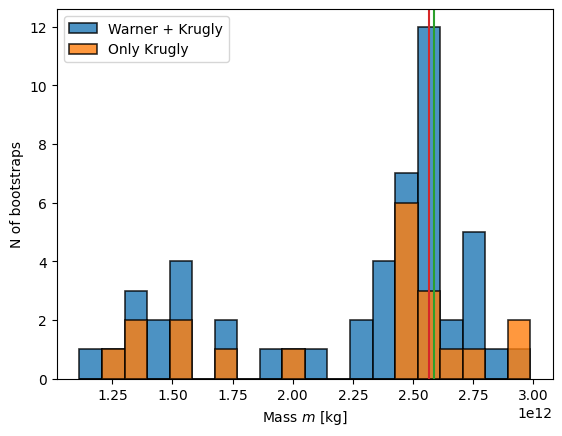

In [20]:
# estimate mass from the parameters of the asteroid
masses_all = np.concatenate([masses, masses_w])
counts, bins = np.histogram(masses_all, bins=20)
plt.hist(masses_w, bins=bins, edgecolor='black', linewidth=1.2, density=False, alpha=0.8, label='Warner + Krugly', color='tab:blue')
plt.hist(masses, bins=bins, edgecolor='black', linewidth=1.2, density=False, alpha=0.8, label='Only Krugly', color='tab:orange')
plt.xlabel((r"Mass $m$ [kg]"))
plt.ylabel('N of bootstraps')
plt.axvline(best_mass_w, color='tab:red')
plt.axvline(best_mass, color='tab:green')
plt.legend()
#plt.savefig('article_images/bulk_density.pdf', bbox_inches='tight', format='pdf')
print(f"mass diff_q17: {abs(mass_q17_w - mass_q17):.2e}, mass diff_q83: {abs(mass_q83_w - mass_q83):.2e}")
print(f"{best_mass_w - best_mass:.2e}, {-(best_mass_w - mass_q17_w):.2e}, +{(best_mass_w - mass_q83_w):.2e}")

## Read selected MCMC samples

In [57]:
import pickle
thin = 1
file_pick = open('mcmc_samples_2025/both_mcmc_24_02_2025_warner.obj', 'rb')
#file_pick = open('mcmc_samples_final/mcmc_full_2.obj', 'rb')
sampler = pickle.load(file_pick)
samples = sampler.get_chain(flat=True) * (sampler.params_max - sampler.params_min) + sampler.params_min
samples = samples[::thin]
flat_ln = sampler.flatlnprobability#[::thin][np.isfinite(sampler.flatlnprobability[::thin])]
min_arg = flat_ln.argmax()
min_chi = flat_ln[min_arg]
samples = samples[np.argwhere(flat_ln != -np.inf), :][:, 0]
print(f'len_samples_all: {len(samples)}', f'len_samples_notna: {len(samples)}')
print(f"min_arg: {min_arg}, min_chi: {min_chi}")
best_params = samples[min_arg]
print("""best_params: a1 = {:.2f},  b1 = {:.2f}, c1 = {:.2f},
             a2 = {:.2f}, b2 = {:.2f}, c2 = {:.2f},
             lon = {:.2f}, lat = {:.2f}, phase = {:.2f}""".format(*best_params))


print('best:      ', [round(float(param), 4) for param in best_params])

len_samples_all: 7913882 len_samples_notna: 7913882
min_arg: 7531914, min_chi: -42374.84370039749
best_params: a1 = 1.41,  b1 = 0.83, c1 = 0.83,
             a2 = 1.02, b2 = 1.02, c2 = 0.40,
             lon = 1.46, lat = -1.39, phase = 1.74
best:       [1.4107, 0.831, 0.8288, 1.0231, 1.0231, 0.3979, 1.4626, -1.3884, 1.7369, 0.2091, 2499.0064, 2.0329]


In [58]:
samples_flat = sampler.flatchain * (sampler.params_max - sampler.params_min) + sampler.params_min#* std_params + mean_params
best_params = samples_flat[min_arg]
print(best_params)

[ 1.40290278e+00  8.31067511e-01  8.26273375e-01  1.04212545e+00
  1.04012286e+00  3.78053397e-01  1.39839125e+00 -1.39085876e+00
  1.67111795e+00  2.09087263e-01  2.34426436e+03  2.02283467e+00]


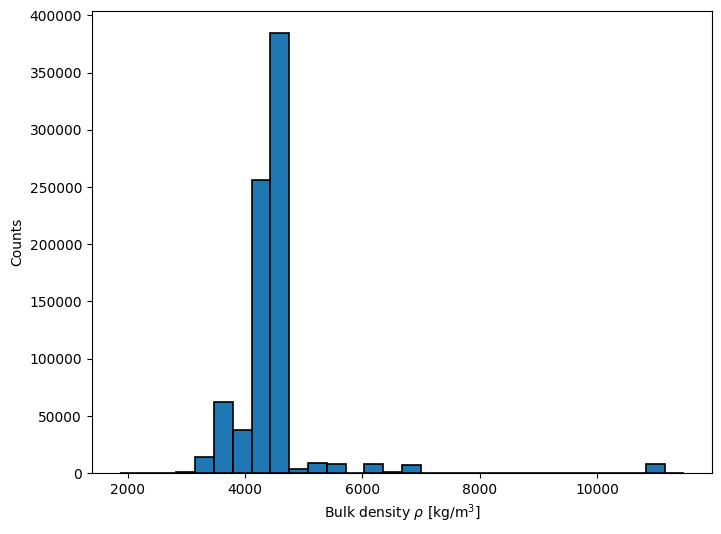

In [23]:
# density from mcmc samples
# calculate the density for the asteroid
density = func.estimate_density(*samples[:, :6].T, rot_per=samples[:, 9])
plt.figure(figsize=(8, 6))
plt.xlabel(r"Bulk density $\rho$ [kg/m$^3$]")
plt.ylabel("Counts")
plt.hist(density, bins=30, edgecolor='black', linewidth=1.2, density=False)
# set logscale
#plt.yscale('log')
plt.show()